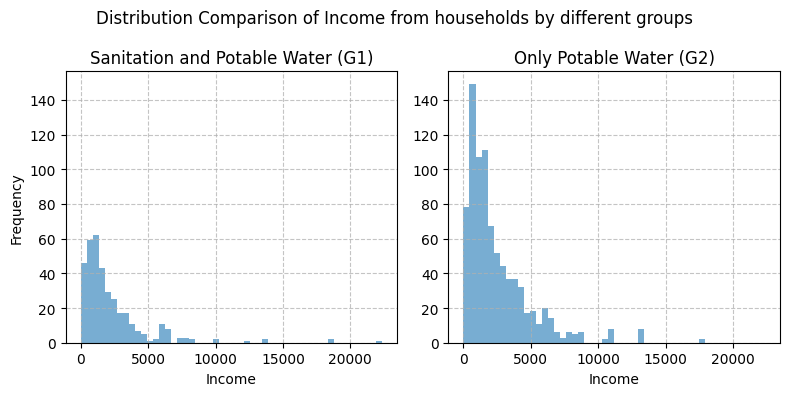

In [132]:
import pandas as pd
import numpy as np
from math import ceil
from matplotlib import pyplot as plt

total_subscribers = 1000
sanitation_subscribers = 300

eps = 1200
std = 0.05

df = pd.read_excel("data/data_La_Réunion_2.xls", "esfact7-ElPR1")

np.random.seed(42)
is_g1 = df['Assainissement Collectif (1 = oui)'] == 1
g1_perc = sanitation_subscribers / total_subscribers
g1_card = int(eps * g1_perc)
g2_card = eps - g1_card
g2_card, g1_card, len(df)
g1_augmented = pd.concat([df[is_g1]] * ceil(g1_card / len(df[is_g1]))).sample(g1_card)
g2_augmented = pd.concat([df[~is_g1]] * ceil(g2_card / len(df[~is_g1]))).sample(g2_card)
g1_augmented['Revenu_Imputé_2'] = g1_augmented[('Revenu_Imputé_2')] + np.random.normal(0, std, g1_card)
g2_augmented['Revenu_Imputé_2'] = g2_augmented[('Revenu_Imputé_2')] + np.random.normal(0, std, g2_card)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].hist(g1_augmented['Revenu_Imputé_2'], bins=50, alpha=0.6, range=(0, df['Revenu_Imputé_2'].max()), label='Sanitation and Potable Water (G1)', )
axs[1].hist(g2_augmented['Revenu_Imputé_2'], bins=50, alpha=0.6, range=(0, df['Revenu_Imputé_2'].max()), label='Only Potable Water (G2)',)
axs[0].set_xlabel("Income")
axs[1].set_xlabel("Income")
axs[0].set_ylabel("Frequency")
plt.suptitle("Distribution Comparison of Income from households by different groups")
axs[0].set_title("Sanitation and Potable Water (G1)")
axs[1].set_title("Only Potable Water (G2)")
axs[0].grid(True, alpha=0.75, linestyle='--')
axs[1].grid(True, alpha=0.75, linestyle='--')
max_ylim = max(axs[0].get_ylim()[1], axs[1].get_ylim()[1])
axs[0].set_ylim(0, max_ylim)
axs[1].set_ylim(0, max_ylim)

mean_g1 = g1_augmented['nbpers'].mean()
mean_g2 = g2_augmented['nbpers'].mean()

plt.tight_layout()
plt.show()

In [98]:
g2_augmented

,i_new,Revenu_Imputé_2,Unnamed: 2,Freq Nombre de Jours sans pluie,nbjour,nbjsp,uc1,revenu,Revenu imputé,nbpers,nenf,naa (Nombre d'adultes actifs),nana (Nombre d'adultes non actifs),jardin (1 = oui),Piscine (1 = oui),Assainissement Collectif (1 = oui),NonAssaini,maison (1 = oui),retraité (1 = oui),proprio (1 = oui)
76,77,2192.489850,77,0.625000,152,95,2.7,3,1093,4,2,2,0,1,0,0,1,1,0,1
45,46,959.570188,46,0.172222,180,31,3.6,3,1093,5,1,3,1,1,0,0,1,1,0,0
245,246,1370.588254,246,0.826087,138,114,1.7,2,3569,2,0,1,1,1,0,0,1,1,0,1
24,25,2662.416671,25,0.948454,97,92,2.7,3,1093,4,2,0,2,1,0,0,1,1,0,1
21,22,7820.712440,22,0.589189,185,109,3.1,7,7374,4,0,2,2,1,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342,343,7079.046842,343,0.940397,151,142,1.7,2,3564,2,0,0,2,1,0,0,1,1,1,1
339,340,4034.021140,340,0.545455,176,96,1.7,1,2187,2,0,1,1,1,0,0,1,1,0,1
75,76,3077.155649,76,0.680982,163,111,3.6,2,3569,5,1,2,2,1,0,0,1,1,0,1
0,1,226.948708,1,0.272727,99,27,2.7,1,2187,4,2,2,0,1,0,0,1,1,0,1
